In [1]:
import cooler
import cooltools
from ggner_3d.boundaries import preserved_boundaries_only, make_tads, assign_domain_score
from ggner_3d.cm import prepare_view_df
import pandas as pd
import numpy as np
from coolpuppy import coolpup
from ggner_3d import plotting

from ggner_3d.cm import MCOOLS_PATH_DICT

plotting.update_rcparams()

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

resolution = 100_000

mcool_control=MCOOLS_PATH_DICT['WTnoUV']
mcool_degron=MCOOLS_PATH_DICT['XPCnoUV']

### cis decay

In [2]:
control_clr = cooler.Cooler(f'{mcool_control}::/resolutions/{resolution}')

view_df = pd.DataFrame({'chrom': control_clr.chromnames,
                        'start': 0,
                        'end': control_clr.chromsizes.values,
                        'name': control_clr.chromnames}
                      )

In [ ]:


control_expected = cooltools.expected_cis(
            clr=control_clr,
            nproc=10,
            view_df = view_df,
            clr_weight_name='weight',
        )

INFO:root:creating a Pool of 10 workers


In [3]:
degron_clr = cooler.Cooler(f'{mcool_degron}::/resolutions/{resolution}')

In [ ]:

degron_expected = cooltools.expected_cis(
            clr=degron_clr,
            nproc=10,
            view_df = view_df,
            clr_weight_name='weight',
        )

INFO:root:creating a Pool of 10 workers


In [18]:
import numpy as np

def prepare_cvd(df, max_dist=None):
    cvd = df.copy()

    # Safe assignment
    cvd.loc[cvd['dist'] < 2, 'balanced.avg.smoothed'] = np.nan
    cvd.loc[cvd['dist'] < 2, 'balanced.avg.smoothed.agg'] = np.nan

    cvd = cvd.drop_duplicates(subset=['dist'])[['dist_bp', 'balanced.avg.smoothed.agg']]

    # Filter distance range early
    if max_dist is not None:
        cvd = cvd[cvd['dist_bp'] <= max_dist]
    else:
        cvd = cvd[cvd['dist_bp'] > 0]  # Ensure we don't have zero or negative distances

    # Remove NaNs before normalization
    cvd = cvd.dropna()

    # Ensure positive values only
    cvd = cvd[cvd['balanced.avg.smoothed.agg'] > 0]
    cvd = cvd[cvd['dist_bp'] > 0]

    # Normalize by AUC
    auc = np.trapz(cvd['balanced.avg.smoothed.agg'], cvd['dist_bp'])
    if auc == 0 or not np.isfinite(auc):
        raise ValueError("AUC is zero or invalid — cannot normalize.")

    cvd['balanced.avg.smoothed.agg'] /= auc

    # Derivative in log-log space
    der = np.gradient(
        np.log(cvd['balanced.avg.smoothed.agg']),
        np.log(cvd['dist_bp'])
    )

    return cvd, der


control_merged, control_der = prepare_cvd(control_expected, max_dist=None)
degron_merged, degron_der = prepare_cvd(degron_expected, max_dist=None)

/tmp/ipykernel_258892/2449072195.py:26: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(cvd['balanced.avg.smoothed.agg'], cvd['dist_bp'])
/tmp/ipykernel_258892/2449072195.py:26: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(cvd['balanced.avg.smoothed.agg'], cvd['dist_bp'])


In [19]:
control_merged['balanced.avg.smoothed.agg'] /= control_merged['balanced.avg.smoothed.agg'].sum()
degron_merged['balanced.avg.smoothed.agg'] /= degron_merged['balanced.avg.smoothed.agg'].sum()

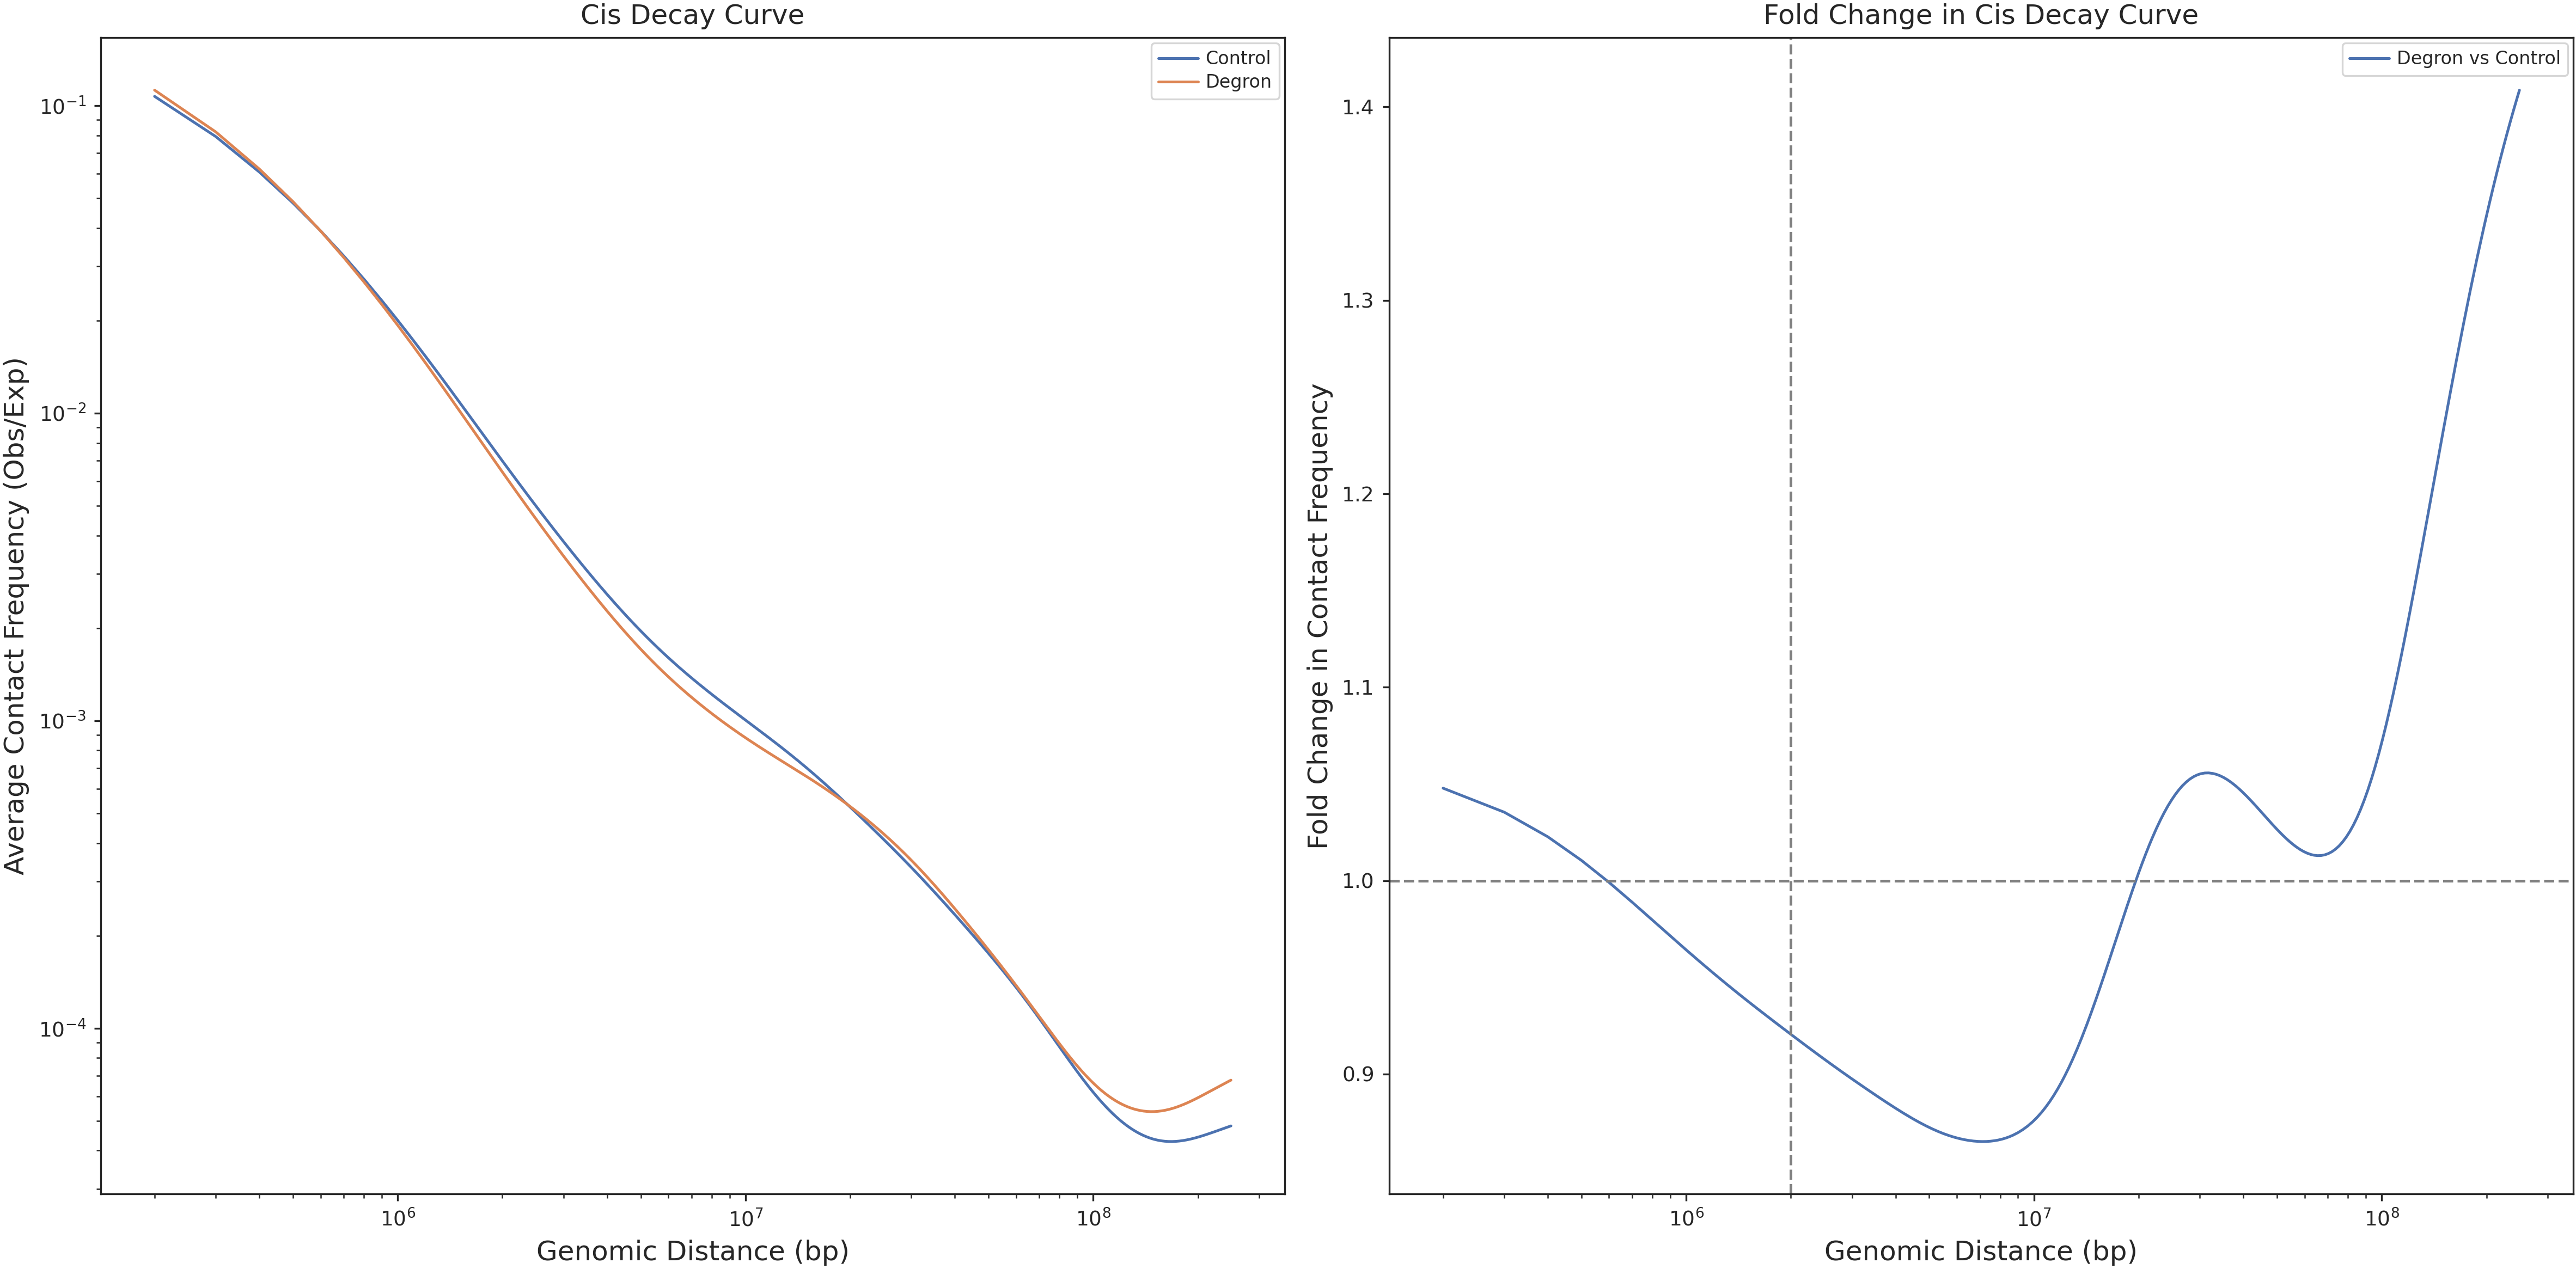

In [21]:
import seaborn as sns
from matplotlib import pyplot as plt

fig, ax = plt.subplots(1,2, figsize=(16, 8))
sns.lineplot(x=control_merged['dist_bp'], y=control_merged['balanced.avg.smoothed.agg'], ax=ax[0], label='Control')
sns.lineplot(x=degron_merged['dist_bp'], y=degron_merged['balanced.avg.smoothed.agg'], ax=ax[0], label='Degron')

# set loglog
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_xlabel('Genomic Distance (bp)')
ax[0].set_ylabel('Average Contact Frequency (Obs/Exp)')
ax[0].set_title('Cis Decay Curve')
ax[0].legend()


foldchange = degron_merged['balanced.avg.smoothed.agg'] / control_merged['balanced.avg.smoothed.agg']
sns.lineplot(x=control_merged['dist_bp'], y=foldchange, ax=ax[1], label='Degron vs Control')
ax[1].set_xscale('log')
ax[1].set_xlabel('Genomic Distance (bp)')
ax[1].set_ylabel('Fold Change in Contact Frequency')
ax[1].set_title('Fold Change in Cis Decay Curve')
# add horizontal line at y=0
ax[1].axhline(1, color='gray', linestyle='--')
ax[1].legend()
# add vertical line at x=2Mb
ax[1].axvline(2e6, color='gray', linestyle='--')
plt.tight_layout()

### compartments

In [ ]:
from cooltools import eigs_cis

import multiprocess as mp
pool = mp.Pool(10)
resolution = 100_000

Process ForkPoolWorker-8:
Process ForkPoolWorker-9:
Process ForkPoolWorker-6:
Process ForkPoolWorker-7:
Process ForkPoolWorker-3:
Process ForkPoolWorker-2:
Process ForkPoolWorker-4:
Process ForkPoolWorker-1:
Process ForkPoolWorker-5:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/carlos/Clone/ggner-3d/.venv/lib/python3.12/site-packages/multiprocess/process.py", line 314, in _bootstrap
    self.run()
Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/carlos/Clone/ggner-3d/.venv/lib/python3.12/site-packages/multiprocess/process.py", line 314, in _bootstrap
    self.run()
  File "/home/carlos/Clone/ggner-3d/.venv/lib/python3.12/site-packages/multiprocess/process.py", line 314, in _bootstrap
    self.run()
  File "/home/carlos/Clone/ggner-3d/.venv/lib/python3.12/site-packages/multiprocess/process.py", line 108, in run

In [6]:
import bioframe
bins = control_clr.bins()[:]
hg38_genome = bioframe.load_fasta('/home/carlos/Clone/ggner-3d/data/degron_wapl/hg38.fa')
gc_cov = bioframe.frac_gc(bins[['chrom', 'start', 'end']], hg38_genome)

OSError: file `/home/carlos/Clone/ggner-3d/data/degron_wapl/hg38.fa` not found

In [ ]:
view_df = pd.DataFrame({'chrom': control_clr.chromnames,
                        'start': 0,
                        'end': control_clr.chromsizes.values,
                        'name': control_clr.chromnames}
                      )

_, eigvec_table_control = cooltools.eigs_cis(
    clr=control_clr,
    phasing_track=gc_cov,
    view_df=view_df,
    n_eigs=3,
    clr_weight_name='weight',
    sort_metric='MAD_explained',
    map=pool.map
)

_, eigvec_table_degron = cooltools.eigs_cis(
    clr=degron_clr,
    phasing_track=gc_cov,
    view_df=view_df,
    n_eigs=3,
    clr_weight_name='weight',
    sort_metric='MAD_explained',
    map=pool.map
)

In [ ]:
from scipy.stats import pearsonr
bad_chroms = []
for chrom in eigvec_table_control['chrom'].unique():
    control_e1 = eigvec_table_control[eigvec_table_control['chrom'] == chrom]['E1']
    degron_e1 = eigvec_table_degron[eigvec_table_degron['chrom'] == chrom]['E1']
    both_non_na = np.isfinite(control_e1) & np.isfinite(degron_e1)

    if control_e1[both_non_na].empty or degron_e1[both_non_na].empty:
        print(f"Chromosome {chrom}: Not enough data for correlation.")
        bad_chroms.append(chrom)
        continue
    corr, pval = pearsonr(control_e1[both_non_na], degron_e1[both_non_na])
    if corr < 0.8:
        print(f"Chromosome {chrom}: Low correlation of E1 between control and degron: {corr:.4f} (p={pval:.2e})")
        bad_chroms.append(chrom)

view_df_filtered = view_df[~view_df['chrom'].isin(bad_chroms)]

In [ ]:
control_expected = cooltools.expected_cis(
            clr=control_clr,
            nproc=10,
            view_df = view_df,
            clr_weight_name='weight',
        )

degron_expected = cooltools.expected_cis(
            clr=degron_clr,
            nproc=10,
            view_df = view_df,
            clr_weight_name='weight',
        )

In [ ]:
eigenvector_track_control = eigvec_table_control[['chrom','start','end','E1']].loc[~eigvec_table_control['chrom'].isin(bad_chroms)]
eigenvector_track_degron = eigvec_table_degron[['chrom','start','end','E1']].loc[~eigvec_table_degron['chrom'].isin(bad_chroms)]


N_GROUPS = 50
Q_LO, Q_HI = 0.025, 0.975

interaction_sum_c, interaction_count_c =  cooltools.saddle(
        control_clr,
        control_expected,
        eigenvector_track_control,
        'cis',
        n_bins=N_GROUPS,
        qrange=(Q_LO,Q_HI),
        view_df=view_df
)

interaction_sum_d, interaction_count_d =  cooltools.saddle(
        degron_clr,
        degron_expected,
        eigenvector_track_degron,
        'cis',
        n_bins=N_GROUPS,
        qrange=(Q_LO,Q_HI),
        view_df=view_df
)

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

vmin = np.nanmin(interaction_sum_c / interaction_count_c)
vmax = np.nanmax(interaction_sum_c / interaction_count_c)

sns.heatmap(interaction_sum_c / interaction_count_c, cmap='vlag', center=1, ax=axs[0], vmin=vmin, vmax=vmax, square=True)
axs[0].set_title('Control Saddle Plot (E1)')
sns.heatmap(interaction_sum_d / interaction_count_d, cmap='vlag', center=1, ax=axs[1], vmin=vmin, vmax=vmax, square=True)
axs[1].set_title('Degron Saddle Plot (E1)')

delta = (interaction_sum_d / interaction_count_d) - (interaction_sum_c / interaction_count_c)
sns.heatmap(delta, cmap='vlag', center=0, ax=axs[2], square=True)
axs[2].set_title('Delta Saddle Plot (Degron - Control)')

In [ ]:
from cooltools.api.saddle import saddle_strength

saddle_c = (interaction_sum_c, interaction_count_c)
saddle_d = (interaction_sum_d, interaction_count_d)

for name, saddle in [('Control', saddle_c), ('Degron', saddle_d)]:
    x = np.arange(N_GROUPS + 2)

    plt.step(x, np.log2(saddle_strength(saddle[0], saddle[1])), where='pre', label=name)

    plt.xlabel('extent')
    plt.ylabel('log2 (AA + BB) / (AB + BA)')
    plt.title('saddle strength profile')
    plt.axhline(0, c='grey', ls='--', lw=1)

plt.legend()

### trans

In [5]:
import multiprocess as mp
pool = mp.Pool(6)
pool.close()

control_expected_trans = cooltools.expected_trans(
            clr=control_clr,
            nproc=4,
            view_df = view_df,
            clr_weight_name='weight',
        )

degron_expected_trans = cooltools.expected_trans(
            clr=degron_clr,
            nproc=4,
            view_df = view_df,
            clr_weight_name='weight',
        )

INFO:root:creating a Pool of 4 workers
INFO:root:creating a Pool of 4 workers


In [15]:
from ggner_3d.cm import get_eig_data
control_eig_data = get_eig_data('WTnoUV', 100_000)

eigvec_track = control_eig_data[1][['chrom', 'start', 'end', 'E1']].copy()

N_GROUPS = 50
Q_LO, Q_HI = 0.025, 0.975

interaction_sum_c, interaction_count_c =  cooltools.saddle(
        control_clr,
        control_expected_trans,
        eigvec_track,
        'trans',
        n_bins=N_GROUPS,
        qrange=(Q_LO,Q_HI),
        view_df=view_df
)

interaction_sum_d, interaction_count_d =  cooltools.saddle(
        degron_clr,
        degron_expected_trans,
        eigvec_track,
        'trans',
        n_bins=N_GROUPS,
        qrange=(Q_LO,Q_HI),
        view_df=view_df
)

Text(0.5, 1.0, 'Delta Saddle Plot (XPC KO - WT Control)')

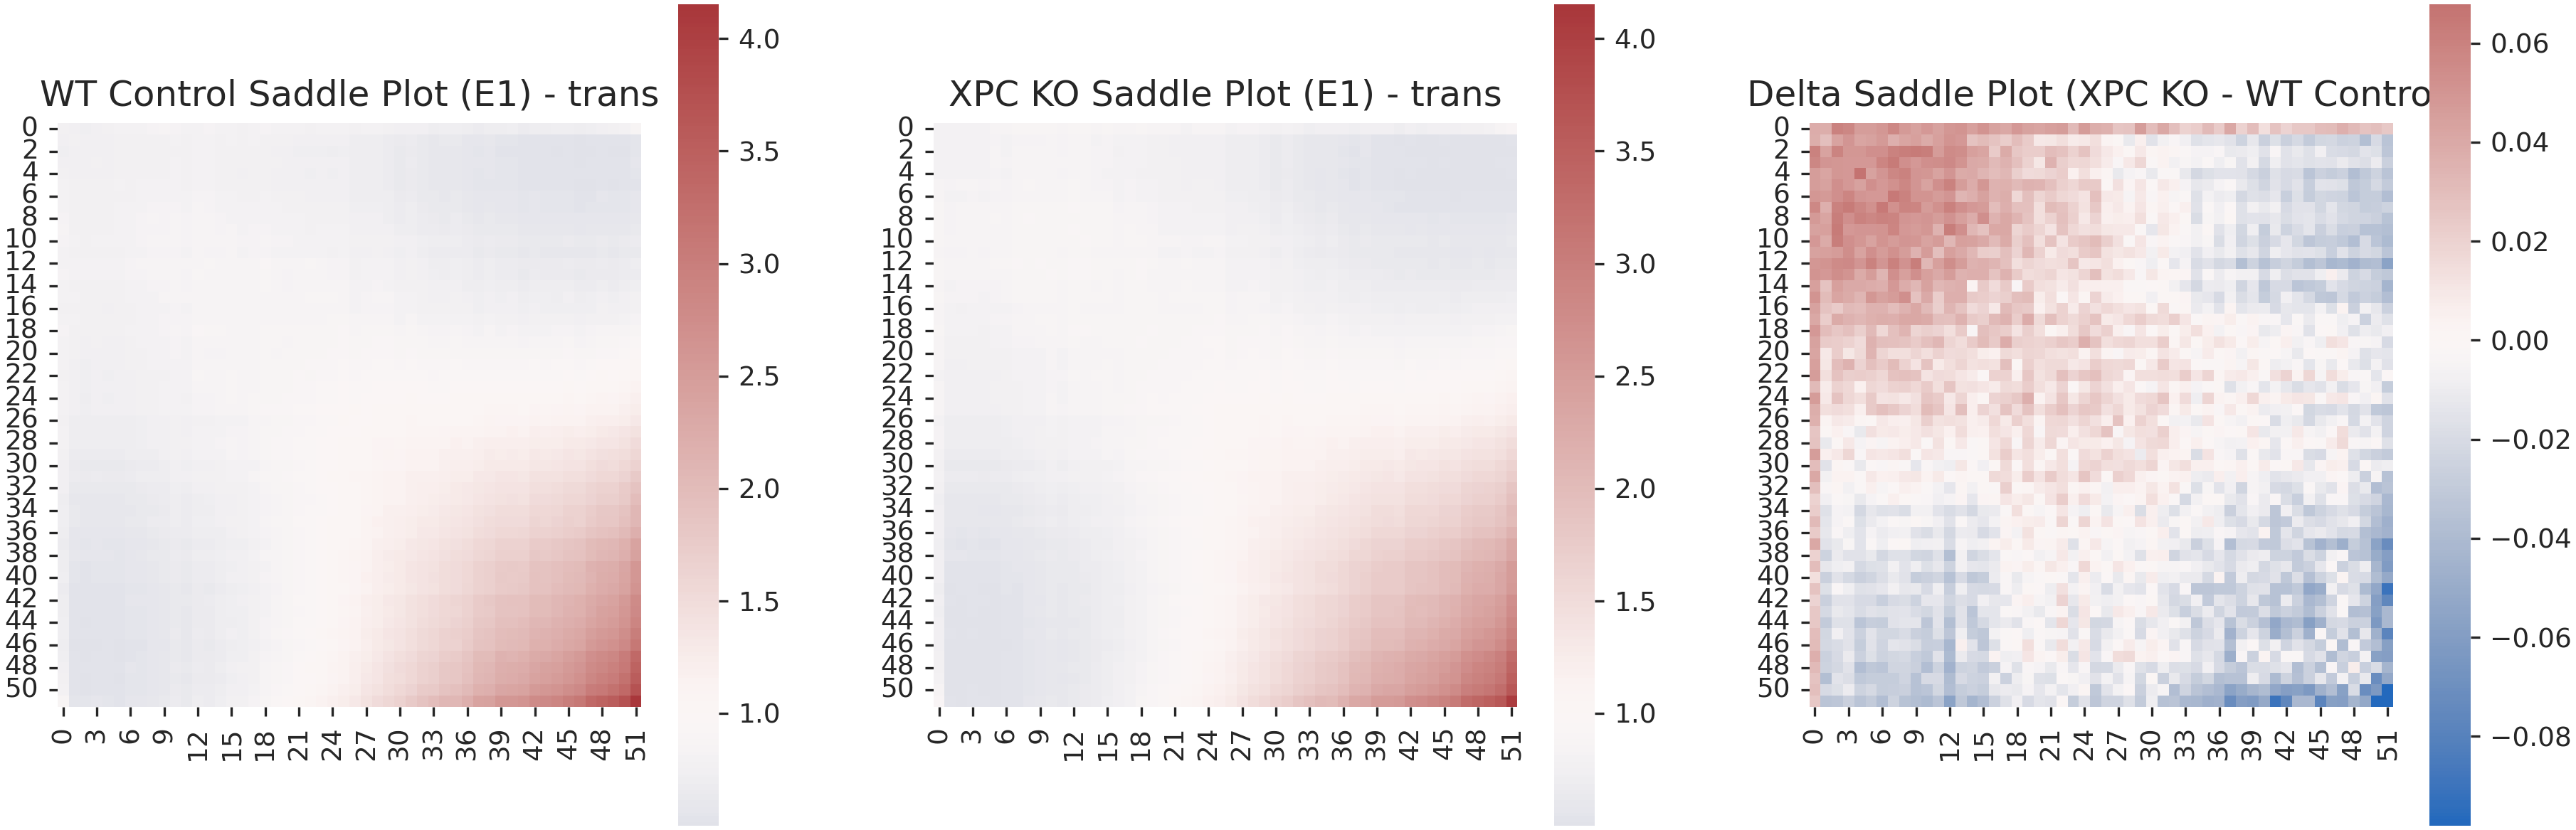

In [16]:
from matplotlib import pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

vmin = np.nanmin(interaction_sum_c / interaction_count_c)
vmax = np.nanmax(interaction_sum_c / interaction_count_c)

sns.heatmap(interaction_sum_c / interaction_count_c, cmap='vlag', center=1, ax=axs[0], vmin=vmin, vmax=vmax, square=True)
axs[0].set_title('WT Control Saddle Plot (E1) - trans')
sns.heatmap(interaction_sum_d / interaction_count_d, cmap='vlag', center=1, ax=axs[1], vmin=vmin, vmax=vmax, square=True)
axs[1].set_title('XPC KO Saddle Plot (E1) - trans')

delta = (interaction_sum_d / interaction_count_d) - (interaction_sum_c / interaction_count_c)
sns.heatmap(delta, cmap='vlag', center=0, ax=axs[2], square=True)
axs[2].set_title('Delta Saddle Plot (XPC KO - WT Control)')

### insulation

In [2]:
resolution = 10_000
window = 500_000

control_clr = cooler.Cooler(f'{mcool_control}::/resolutions/{resolution}')
degron_clr = cooler.Cooler(f'{mcool_degron}::/resolutions/{resolution}')

control_df = pd.read_csv('/home/carlos/Clone/ggner-3d/data/insulation/insulation_WTnoUV_10000bp.csv')
degron_df = pd.read_csv('/home/carlos/Clone/ggner-3d/data/insulation/insulation_XPCnoUV_10000bp.csv')

In [4]:
def chrom_to_bin_indices(df, bins_table, bin_column = 'idx1'):
    df = df.copy()
    bins_table['indices'] = bins_table.index
    return pd.merge(df, bins_table, left_on=bin_column, right_on='indices')

insulation_table_ = [control_df, degron_df]

In [5]:
comparisons = [(0,1)]
comparisons_str = ['control_vs_degron']
sample_names_str = ['control', 'degron']
accepted_range = 1

results, dfs = preserved_boundaries_only(
    comparisons=comparisons,
    comparisons_str=comparisons_str,
    sample_names_str=sample_names_str,
    accepted_range=accepted_range,
    insulation_table_=insulation_table_,
    window=window,
)

dfs = [
    chrom_to_bin_indices(df, control_clr.bins()[:], bin_column='idx1') for df in dfs
]

control_vs_degron: Preserved / Increase ::: 2378
control_vs_degron: Preserved / Decrease ::: 358


In [6]:
common_boundaries = dfs[0].copy()
idx1_bs = control_df.iloc[common_boundaries.idx1, 7]
idx2_bs = degron_df.iloc[common_boundaries.idx2, 7]

common_boundaries['bs1'] = idx1_bs.values
common_boundaries['bs2'] = idx2_bs.values

common_boundaries['delta_bs'] = common_boundaries['bs2'] - common_boundaries['bs1']
common_boundaries['bs_Q'] = pd.qcut(common_boundaries['delta_bs'], q=4, labels=False) + 1

common_tads = make_tads(
    insul_df=dfs[0][['chrom', 'start', 'end']],
    maxlen=3e6)
common_boundaries['bs_Q'].value_counts()

bs_Q
1    684
2    684
3    684
4    684
Name: count, dtype: int64

In [7]:
control_expected = pd.read_csv('/home/carlos/Clone/ggner-3d/data/expected/expected_cis_chrom_WTnoUV_res10kb.tsv', sep='\t')
degron_expected = pd.read_csv('/home/carlos/Clone/ggner-3d/data/expected/expected_cis_chrom_XPCnoUV_res10kb.tsv', sep='\t')

In [8]:
comparisons_tups = [(sample_names_str[i], sample_names_str[j]) for i,j in comparisons]

view_df = prepare_view_df(False)

control_clr = cooler.Cooler(f'{mcool_control}::/resolutions/{resolution}')
degron_clr = cooler.Cooler(f'{mcool_degron}::/resolutions/{resolution}')

cc = coolpup.CoordCreator(common_tads, resolution=10000, features_format='bed', local=True, rescale_flank=1)
pup_s1 = coolpup.PileUpper(control_clr, cc, expected=control_expected, view_df=view_df, ignore_diags=0, rescale_size=99, rescale=True, nproc=10, clr_weight_name='weight').pileupsWithControl()
pup_s2 = coolpup.PileUpper(degron_clr, cc, expected=degron_expected, view_df=view_df, ignore_diags=0, rescale_size=99, rescale=True, nproc=10, clr_weight_name='weight').pileupsWithControl()

INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr9', 'chr9'): 99
INFO:coolpuppy:('chr10', 'chr10'): 100
INFO:coolpuppy:('chr6', 'chr6'): 147
INFO:coolpuppy:('chr8', 'chr8'): 124
INFO:coolpuppy:('chr7', 'chr7'): 127
INFO:coolpuppy:('chr5', 'chr5'): 149
INFO:coolpuppy:('chr4', 'chr4'): 160
INFO:coolpuppy:('chr3', 'chr3'): 164
INFO:coolpuppy:('chr1', 'chr1'): 200
INFO:coolpuppy:('chr15', 'chr15'): 74
INFO:coolpuppy:('chr13', 'chr13'): 73
INFO:coolpuppy:('chr14', 'chr14'): 67
INFO:coolpuppy:('chr16', 'chr16'): 58
INFO:coolpuppy:('chr11', 'chr11'): 134
INFO:coolpuppy:('chr2', 'chr2'): 186
INFO:coolpuppy:('chr19', 'chr19'): 52
INFO:coolpuppy:('chr17', 'chr17'): 68
INFO:coolpuppy:('chr21', 'chr21'): 18
INFO:coolpuppy:('chr22', 'chr22'): 23
INFO:coolpuppy:('chr12', 'chr12'): 120
INFO:coolpuppy:('chr18', 'chr18'): 59
INFO:coolpuppy:('chr20', 'chr20'): 61
INFO:coolpuppy:('chrX', 'chrX'): 93
INFO:coolpuppy:Total number of piled up windows: 2356
INFO:coolpuppy:Re

<Axes: >

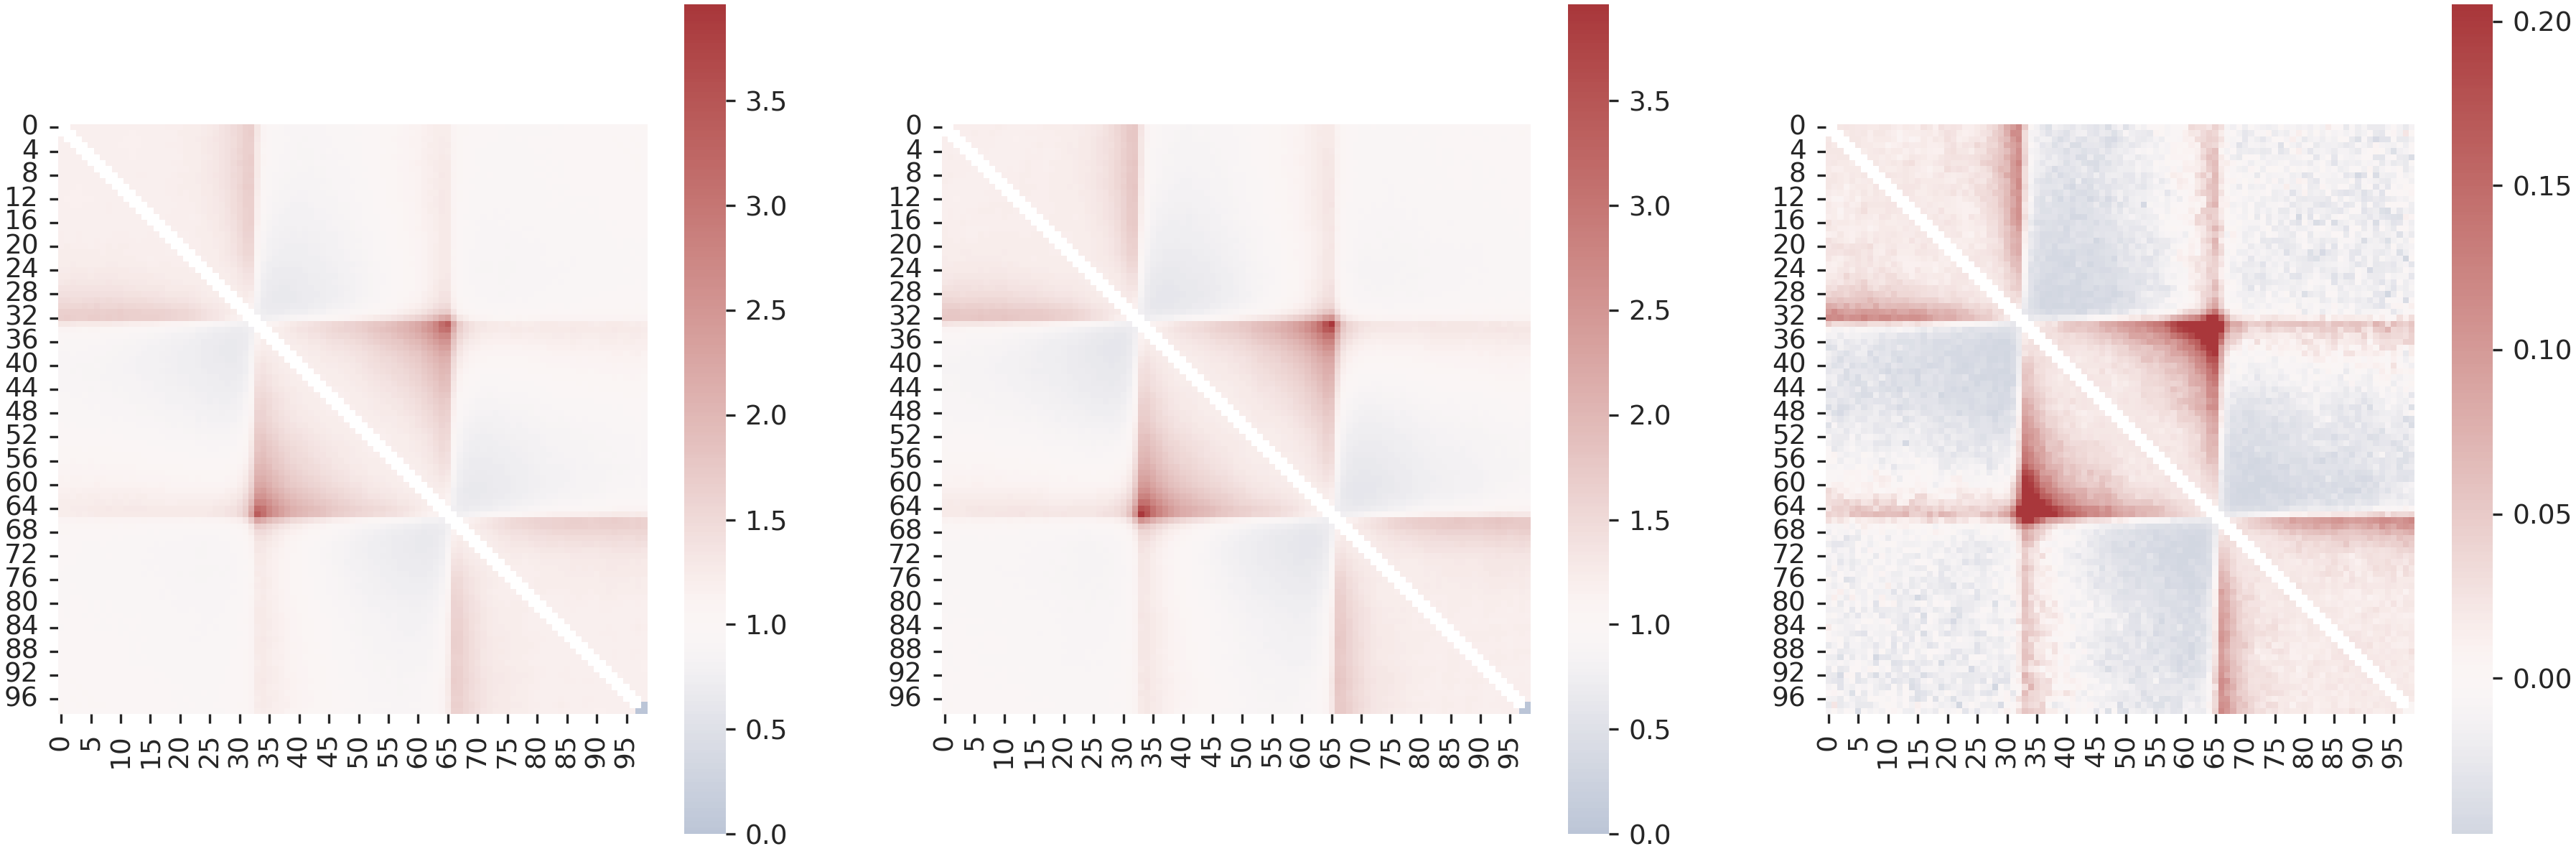

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(15, 5)) 

vmin = min(np.nanmin(pup_s1['data'][0]), np.nanmin(pup_s2['data'][0]))
vmax = max(np.nanmax(pup_s1['data'][0]), np.nanmax(pup_s2['data'][0]))

sns.heatmap(pup_s1['data'][0], cmap='vlag', center=1, square=True, ax=axs[0], vmin=vmin, vmax=vmax)
sns.heatmap(pup_s2['data'][0], cmap='vlag', center=1, square=True, ax=axs[1], vmin=vmin, vmax=vmax)
diff_mtx = pup_s2['data'][0] - pup_s1['data'][0]

diff_vmin = np.nanpercentile(diff_mtx, 0.5)
diff_vmax = np.nanpercentile(diff_mtx, 99.5)

sns.heatmap(diff_mtx, cmap='vlag', center=0, square=True, ax=axs[2], vmin=diff_vmin, vmax=diff_vmax)

### boundaries

In [44]:
boundaries_flank = 1_000_000
cc = coolpup.CoordCreator(common_boundaries, resolution=10000, features_format='bed', local=True, flank=boundaries_flank)
pup_s1 = coolpup.PileUpper(control_clr, cc, expected=control_expected, view_df=view_df, ignore_diags=0, nproc=10, clr_weight_name='weight').pileupsWithControl()
pup_s2 = coolpup.PileUpper(degron_clr, cc, expected=degron_expected, view_df=view_df, ignore_diags=0, nproc=10, clr_weight_name='weight').pileupsWithControl()

INFO:coolpuppy:('chr9', 'chr9'): 111
INFO:coolpuppy:('chr5', 'chr5'): 170
INFO:coolpuppy:('chr6', 'chr6'): 167
INFO:coolpuppy:('chr10', 'chr10'): 119
INFO:coolpuppy:('chr4', 'chr4'): 179
INFO:coolpuppy:('chr7', 'chr7'): 142
INFO:coolpuppy:('chr8', 'chr8'): 138
INFO:coolpuppy:('chr3', 'chr3'): 189
INFO:coolpuppy:('chr1', 'chr1'): 229
INFO:coolpuppy:('chr13', 'chr13'): 84
INFO:coolpuppy:('chr15', 'chr15'): 85
INFO:coolpuppy:('chr11', 'chr11'): 148
INFO:coolpuppy:('chr14', 'chr14'): 82
INFO:coolpuppy:('chr16', 'chr16'): 71
INFO:coolpuppy:('chr19', 'chr19'): 60
INFO:coolpuppy:('chr17', 'chr17'): 74
INFO:coolpuppy:('chr2', 'chr2'): 221
INFO:coolpuppy:('chr18', 'chr18'): 68
INFO:coolpuppy:('chr21', 'chr21'): 25
INFO:coolpuppy:('chr22', 'chr22'): 33
INFO:coolpuppy:('chr12', 'chr12'): 137
INFO:coolpuppy:('chr20', 'chr20'): 69
INFO:coolpuppy:('chrX', 'chrX'): 113
INFO:coolpuppy:Total number of piled up windows: 2714
INFO:coolpuppy:('chr9', 'chr9'): 111
INFO:coolpuppy:('chr6', 'chr6'): 167
INFO:

<Axes: >

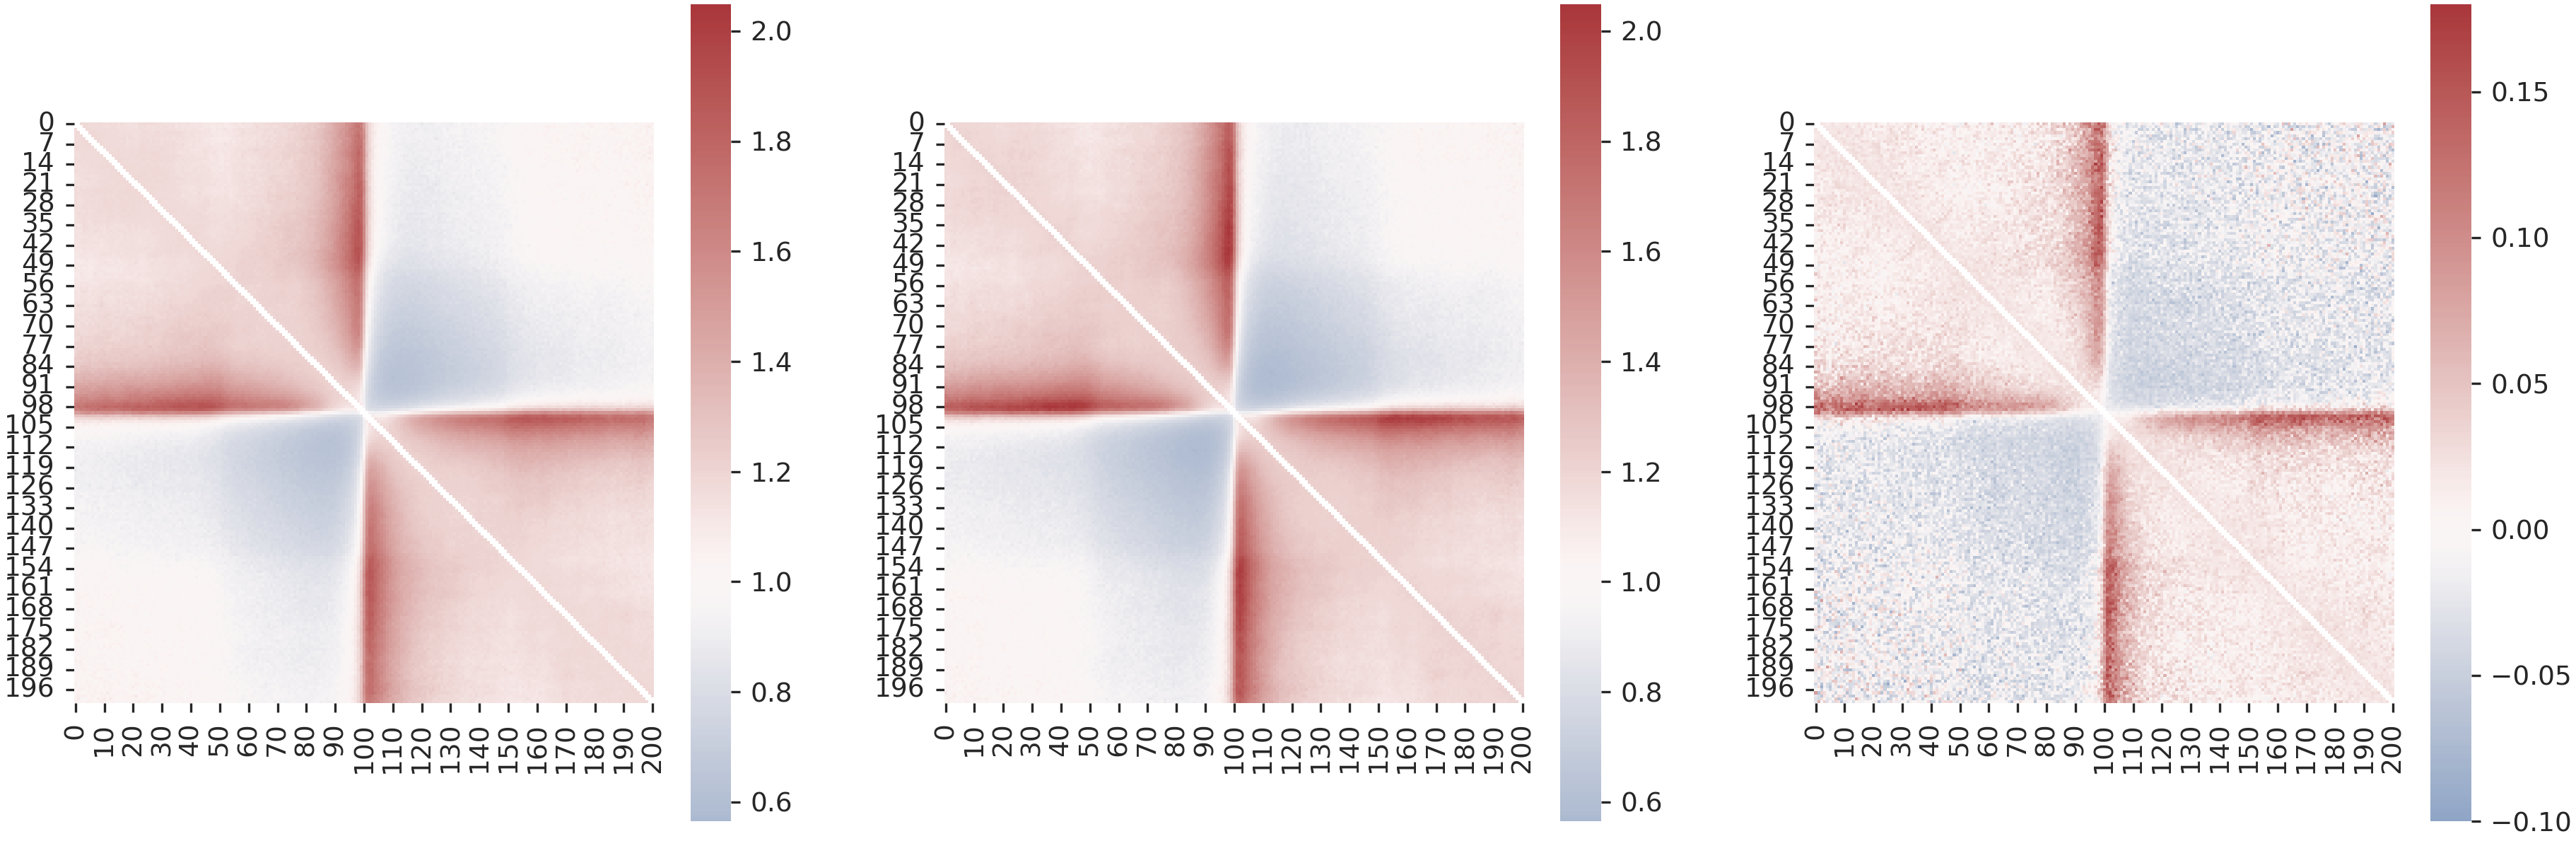

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(15, 5)) 

vmin = min(np.nanmin(pup_s1['data'][0]), np.nanmin(pup_s2['data'][0]))
vmax = max(np.nanmax(pup_s1['data'][0]), np.nanmax(pup_s2['data'][0]))

sns.heatmap(pup_s1['data'][0], cmap='vlag', center=1, square=True, ax=axs[0], vmin=vmin, vmax=vmax)
sns.heatmap(pup_s2['data'][0], cmap='vlag', center=1, square=True, ax=axs[1], vmin=vmin, vmax=vmax)
diff_mtx = pup_s2['data'][0] - pup_s1['data'][0]

diff_vmin = -0.1
diff_vmax = 0.18

sns.heatmap(diff_mtx, cmap='vlag', center=0, square=True, ax=axs[2], vmin=diff_vmin, vmax=diff_vmax)

### compartment

In [11]:
import pandas as pd
import numpy as np

view_df = prepare_view_df(False)

resolution = 100_000

eigvec_table_control = pd.read_csv('/home/carlos/Clone/ggner-3d/data/compartment/compartment_eigvecs_WTnoUV_100000.tsv', sep='\t')
eigvec_table_degron = pd.read_csv('/home/carlos/Clone/ggner-3d/data/compartment/compartment_eigvecs_XPCnoUV_100000.tsv', sep='\t')

control_expected = pd.read_csv('/home/carlos/Clone/ggner-3d/data/expected/expected_cis_chrom_WTnoUV_res100kb.tsv', sep='\t')
degron_expected = pd.read_csv('/home/carlos/Clone/ggner-3d/data/expected/expected_cis_chrom_XPCnoUV_res100kb.tsv', sep='\t')

control_clr = cooler.Cooler(f'{mcool_control}::/resolutions/{resolution}')
degron_clr = cooler.Cooler(f'{mcool_degron}::/resolutions/{resolution}')

from scipy.stats import pearsonr
bad_chroms = []
for chrom in eigvec_table_control['chrom'].unique():
    control_e1 = eigvec_table_control[eigvec_table_control['chrom'] == chrom]['E1']
    degron_e1 = eigvec_table_degron[eigvec_table_degron['chrom'] == chrom]['E1']
    both_non_na = np.isfinite(control_e1) & np.isfinite(degron_e1)

    if control_e1[both_non_na].empty or degron_e1[both_non_na].empty:
        print(f"Chromosome {chrom}: Not enough data for correlation.")
        bad_chroms.append(chrom)
        continue
    corr, pval = pearsonr(control_e1[both_non_na], degron_e1[both_non_na])
    if corr < 0.5:
        print(f"Chromosome {chrom}: Low correlation of E1 between control and degron: {corr:.4f} (p={pval:.2e})")
        bad_chroms.append(chrom)

view_df_filtered = view_df[~view_df['chrom'].isin(bad_chroms)]

In [12]:
eigenvector_track_control = eigvec_table_control[['chrom','start','end','E1']].loc[~eigvec_table_control['chrom'].isin(bad_chroms)]
eigenvector_track_degron = eigvec_table_degron[['chrom','start','end','E1']].loc[~eigvec_table_degron['chrom'].isin(bad_chroms)]


N_GROUPS = 50
Q_LO, Q_HI = 0.025, 0.975

interaction_sum_c, interaction_count_c =  cooltools.saddle(
        control_clr,
        control_expected,
        eigenvector_track_control,
        'cis',
        n_bins=N_GROUPS,
        qrange=(Q_LO,Q_HI),
        view_df=view_df
)

interaction_sum_d, interaction_count_d =  cooltools.saddle(
        degron_clr,
        degron_expected,
        eigenvector_track_degron,
        'cis',
        n_bins=N_GROUPS,
        qrange=(Q_LO,Q_HI),
        view_df=view_df
)

/home/carlos/Clone/ggner-3d/.venv/lib/python3.12/site-packages/cooltools/api/saddle.py:92: RuntimeWarning: divide by zero encountered in divide
  return obs_mat / exp_mat
/home/carlos/Clone/ggner-3d/.venv/lib/python3.12/site-packages/cooltools/api/saddle.py:92: RuntimeWarning: invalid value encountered in divide
  return obs_mat / exp_mat
/home/carlos/Clone/ggner-3d/.venv/lib/python3.12/site-packages/cooltools/api/saddle.py:92: RuntimeWarning: divide by zero encountered in divide
  return obs_mat / exp_mat
/home/carlos/Clone/ggner-3d/.venv/lib/python3.12/site-packages/cooltools/api/saddle.py:92: RuntimeWarning: invalid value encountered in divide
  return obs_mat / exp_mat


Text(0.5, 1.0, 'Delta Saddle Plot (Degron - Control)')

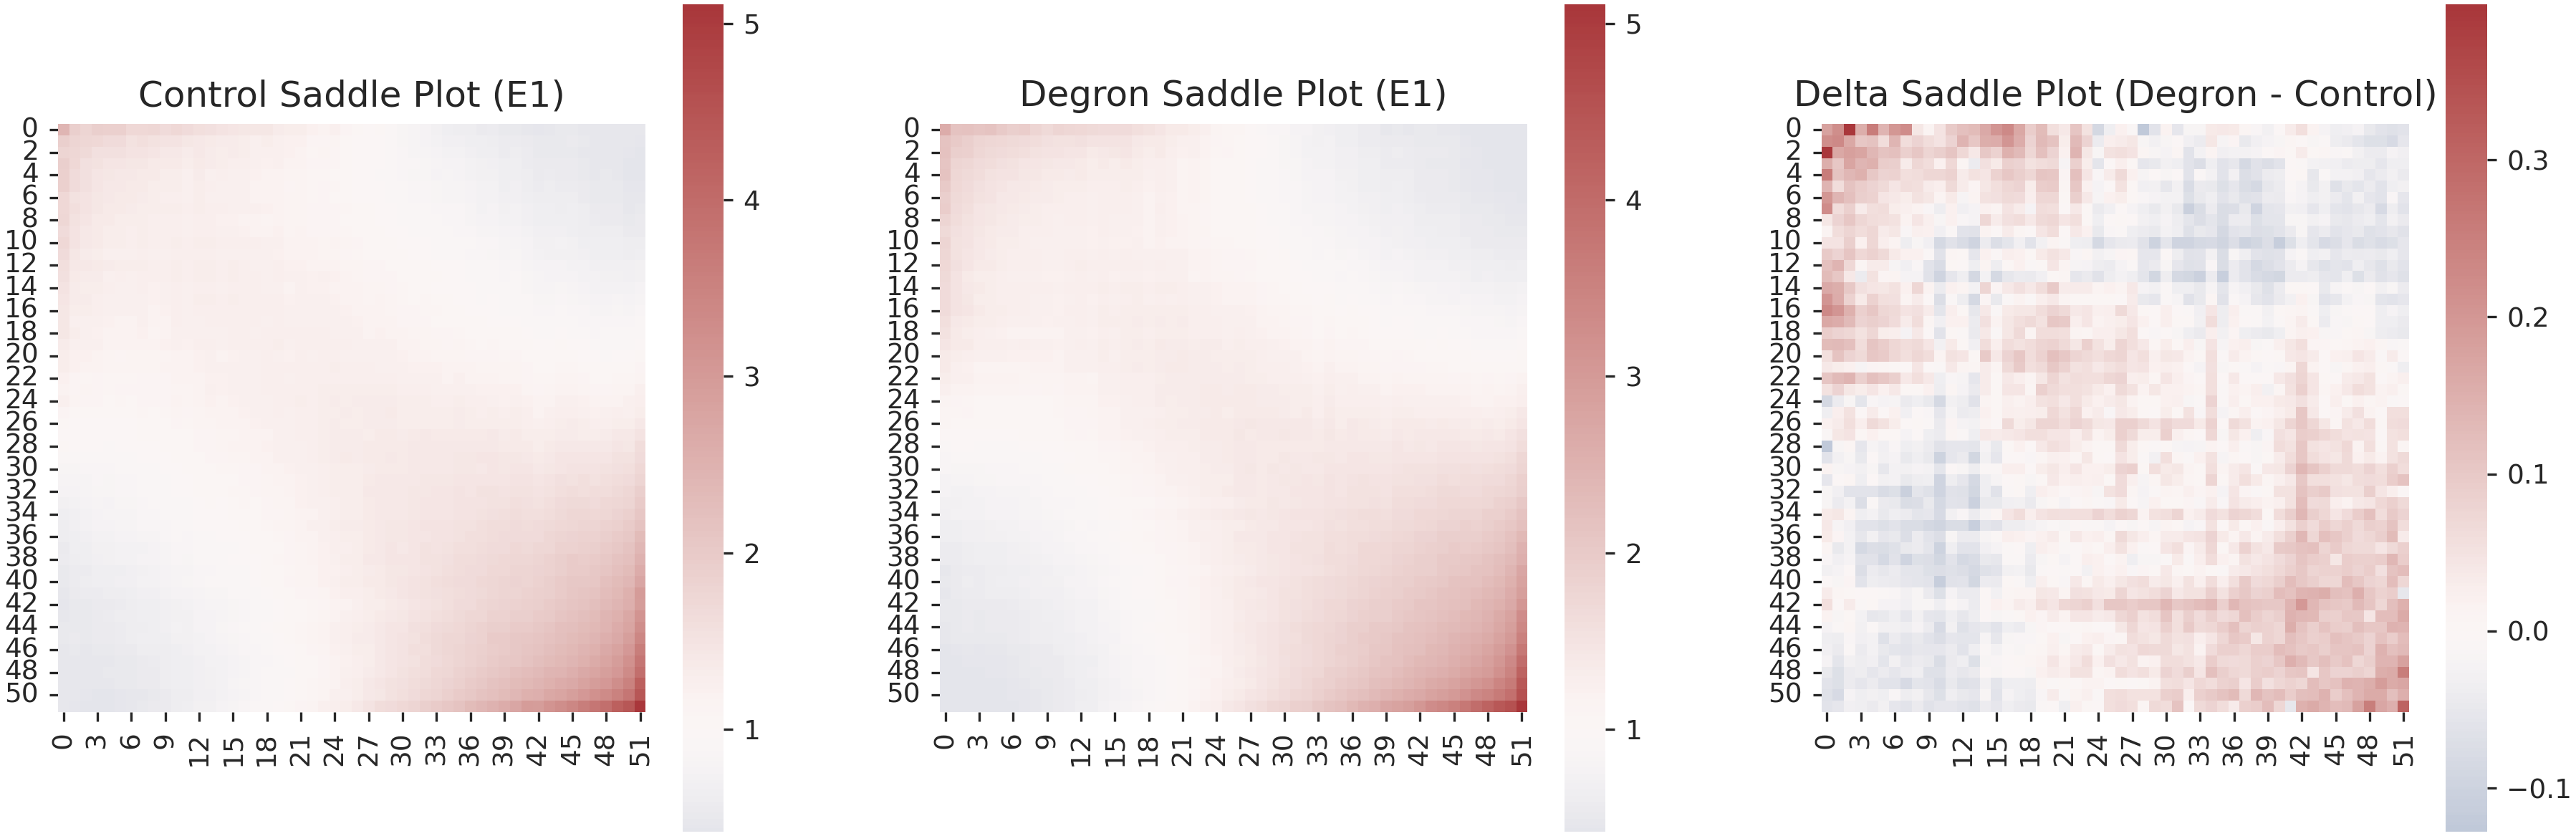

In [15]:
from matplotlib import pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

vmin = np.nanmin(interaction_sum_c / interaction_count_c)
vmax = np.nanmax(interaction_sum_c / interaction_count_c)

sns.heatmap(interaction_sum_c / interaction_count_c, cmap='vlag', center=1, ax=axs[0], vmin=vmin, vmax=vmax, square=True)
axs[0].set_title('Control Saddle Plot (E1)')
sns.heatmap(interaction_sum_d / interaction_count_d, cmap='vlag', center=1, ax=axs[1], vmin=vmin, vmax=vmax, square=True)
axs[1].set_title('Degron Saddle Plot (E1)')

delta = (interaction_sum_d / interaction_count_d) - (interaction_sum_c / interaction_count_c)
sns.heatmap(delta, cmap='vlag', center=0, ax=axs[2], square=True)
axs[2].set_title('Delta Saddle Plot (Degron - Control)')

Text(0.5, 1.0, 'Delta Saddle Plot (Degron - Control)')

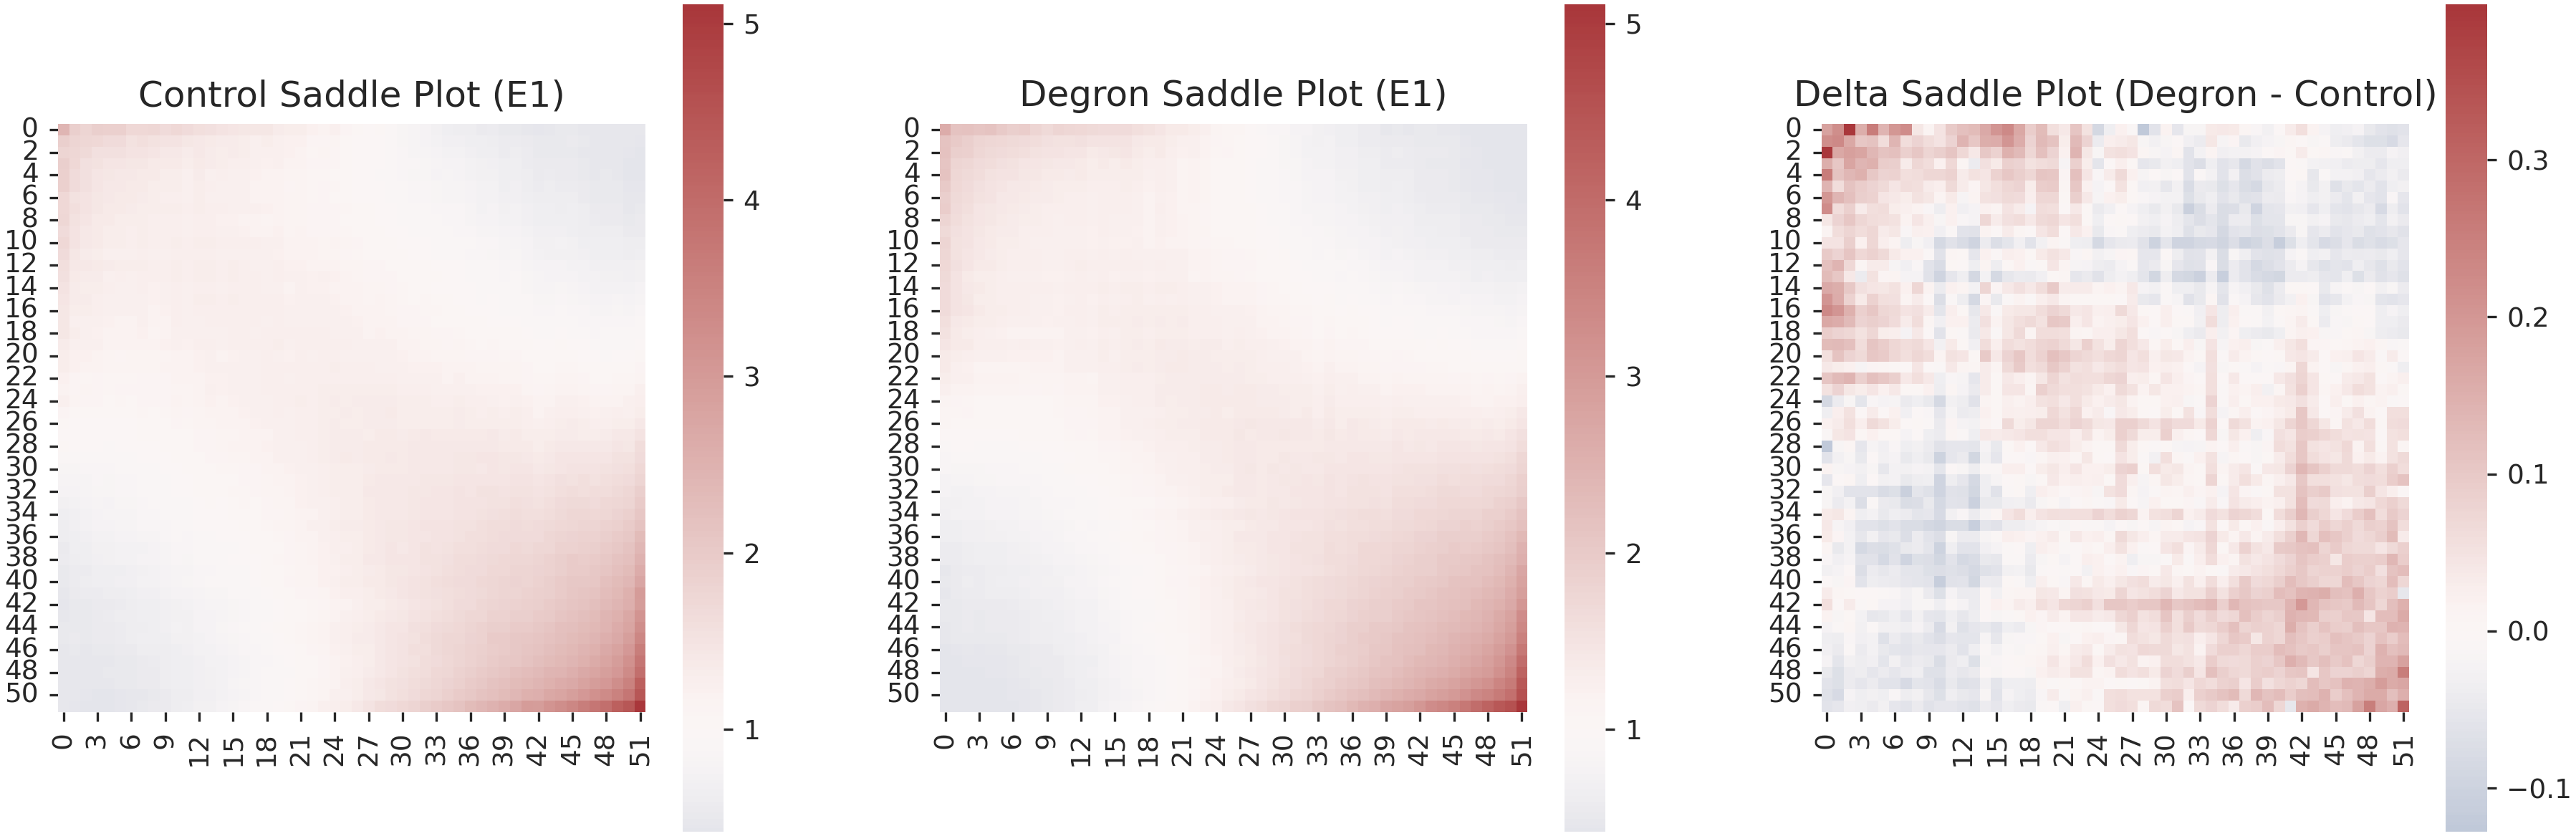

In [16]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

vmin = np.nanmin(interaction_sum_c / interaction_count_c)
vmax = np.nanmax(interaction_sum_c / interaction_count_c)

sns.heatmap(interaction_sum_c / interaction_count_c, cmap='vlag', center=1, ax=axs[0], vmin=vmin, vmax=vmax, square=True)
axs[0].set_title('Control Saddle Plot (E1)')
sns.heatmap(interaction_sum_d / interaction_count_d, cmap='vlag', center=1, ax=axs[1], vmin=vmin, vmax=vmax, square=True)
axs[1].set_title('Degron Saddle Plot (E1)')

delta = (interaction_sum_d / interaction_count_d) - (interaction_sum_c / interaction_count_c)
sns.heatmap(delta, cmap='vlag', center=0, ax=axs[2], square=True)
axs[2].set_title('Delta Saddle Plot (Degron - Control)')

### xpc ko nouv vs 3h

In [19]:
from ggner_3d.cm import CLR_CONNS, get_expected_trans_df
resolution = 100_000
conns = CLR_CONNS(resolution)
clr_xpc_nouv = conns['XPCnoUV']
clr_xpc_3h = conns['XPC3h']

In [21]:
xpc_nouv_trans_expected = get_expected_trans_df('XPCnoUV', resolution_kb=100)
xpc_3h_trans_expected = get_expected_trans_df('XPC3h', resolution_kb=100)

In [29]:
from ggner_3d.cm import get_eig_data
xpc_nouv_eig_data = get_eig_data('XPCnoUV', 100_000)

eigvec_track = xpc_nouv_eig_data[1][['chrom', 'start', 'end', 'E1']].copy()

N_GROUPS = 50
Q_LO, Q_HI = 0.025, 0.975

interaction_sum_c, interaction_count_c =  cooltools.saddle(
        clr_xpc_nouv,
        xpc_nouv_trans_expected,
        eigvec_track,
        'trans',
        n_bins=N_GROUPS,
        qrange=(Q_LO,Q_HI),
        view_df=view_df
)

interaction_sum_d, interaction_count_d =  cooltools.saddle(
        clr_xpc_3h,
        xpc_3h_trans_expected,
        eigvec_track,
        'trans',
        n_bins=N_GROUPS,
        qrange=(Q_LO,Q_HI),
        view_df=view_df
)

KeyboardInterrupt: 

Text(0.5, 1.0, 'Delta Saddle Plot (XPC3h - XPCnoUV) - trans')

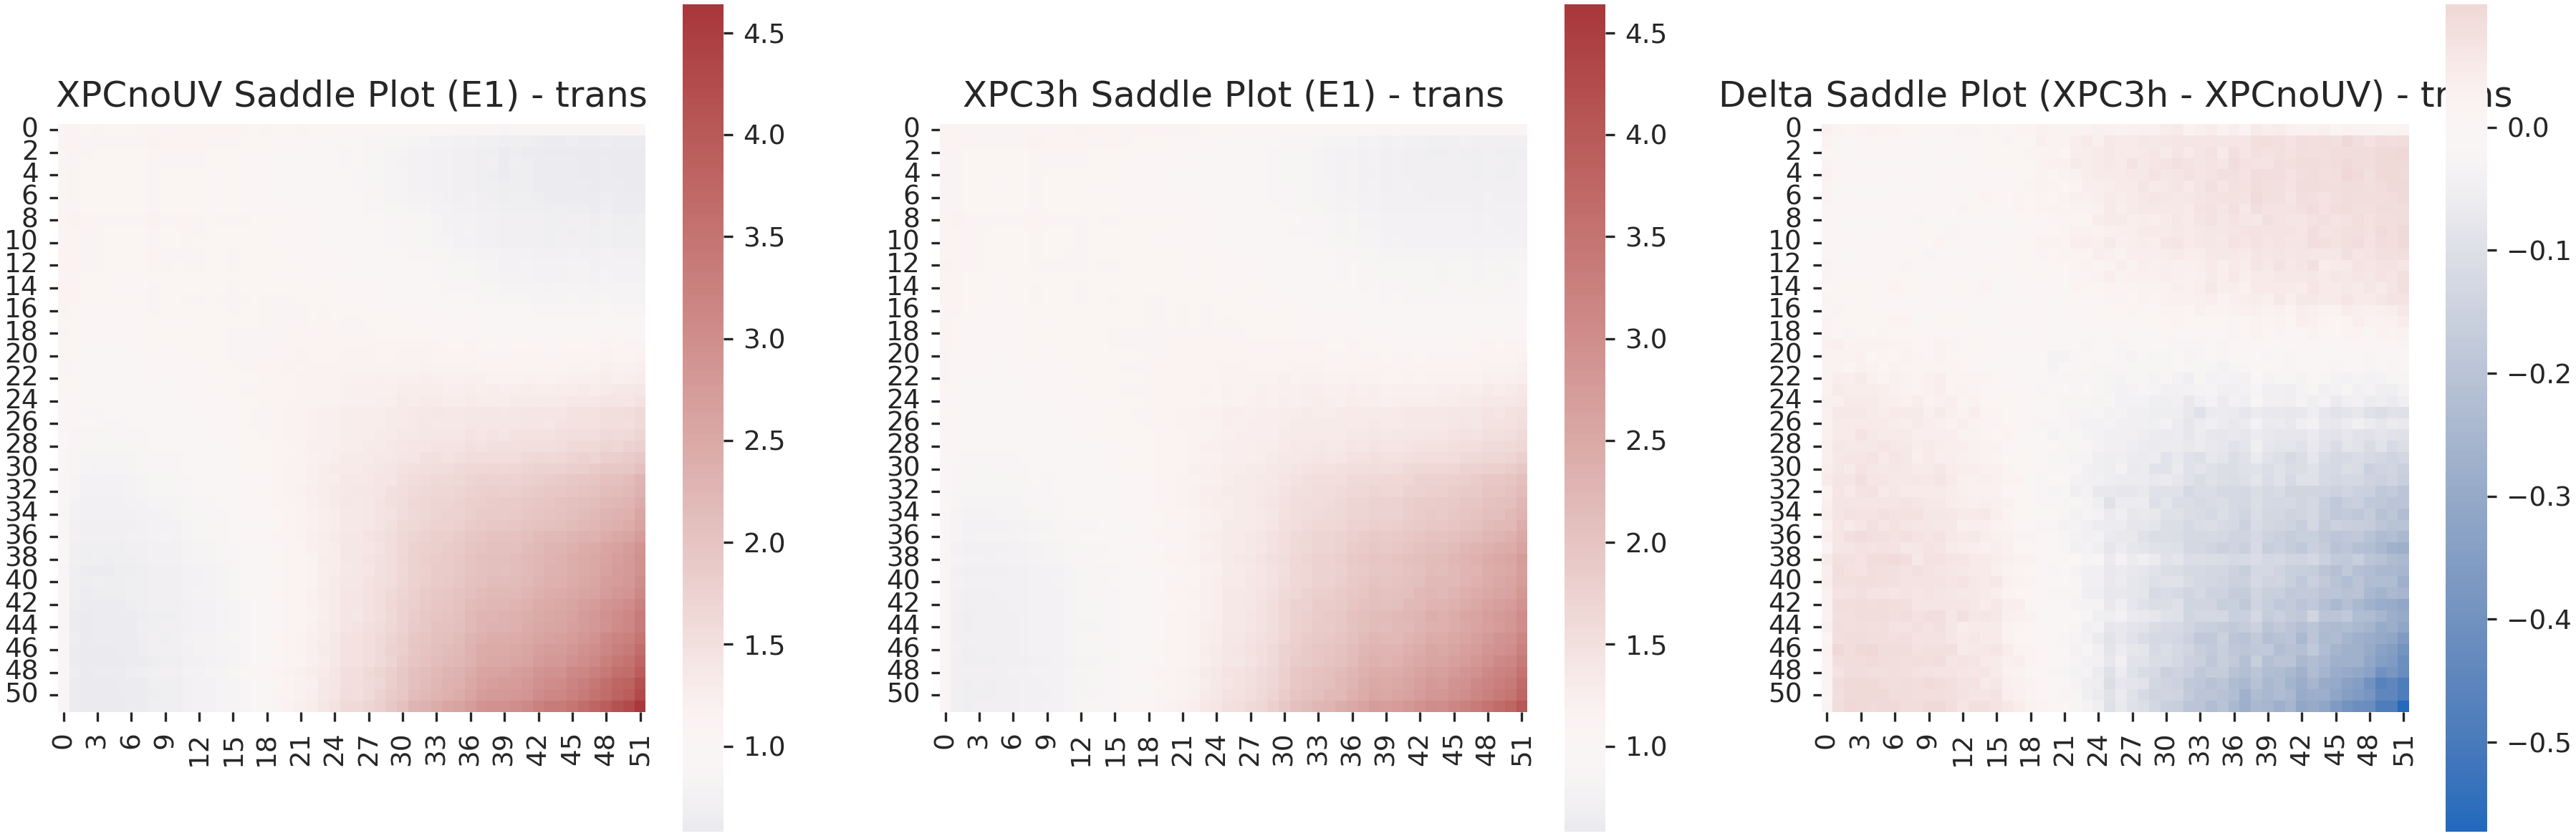

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

vmin = np.nanmin(interaction_sum_c / interaction_count_c)
vmax = np.nanmax(interaction_sum_c / interaction_count_c)

sns.heatmap(interaction_sum_c / interaction_count_c, cmap='vlag', center=1, ax=axs[0], vmin=vmin, vmax=vmax, square=True)
axs[0].set_title('XPCnoUV Saddle Plot (E1) - trans')
sns.heatmap(interaction_sum_d / interaction_count_d, cmap='vlag', center=1, ax=axs[1], vmin=vmin, vmax=vmax, square=True)
axs[1].set_title('XPC3h Saddle Plot (E1) - trans')

delta = (interaction_sum_d / interaction_count_d) - (interaction_sum_c / interaction_count_c)
sns.heatmap(delta, cmap='vlag', center=0, ax=axs[2], square=True)
axs[2].set_title('Delta Saddle Plot (XPC3h - XPCnoUV) - trans')

### wtnouv vs wt3h

In [25]:
from ggner_3d.cm import CLR_CONNS, get_expected_trans_df
resolution = 100_000
conns = CLR_CONNS(resolution)
clr_wt_nouv = conns['WTnoUV']
clr_wt_3h = conns['WT3h']

In [26]:
wt_nouv_trans_expected = get_expected_trans_df('WTnoUV', resolution_kb=100)
wt_3h_trans_expected = get_expected_trans_df('WT3h', resolution_kb=100)

In [30]:
from ggner_3d.cm import get_eig_data
wt_nouv_eig_data = get_eig_data('WTnoUV', 100_000)

eigvec_track = wt_nouv_eig_data[1][['chrom', 'start', 'end', 'E1']].copy()

N_GROUPS = 50
Q_LO, Q_HI = 0.025, 0.975

interaction_sum_c, interaction_count_c =  cooltools.saddle(
        clr_wt_nouv,
        wt_nouv_trans_expected,
        eigvec_track,
        'trans',
        n_bins=N_GROUPS,
        qrange=(Q_LO,Q_HI),
        view_df=view_df
)

interaction_sum_d, interaction_count_d =  cooltools.saddle(
        clr_wt_3h,
        wt_3h_trans_expected,
        eigvec_track,
        'trans',
        n_bins=N_GROUPS,
        qrange=(Q_LO,Q_HI),
        view_df=view_df
)

Text(0.5, 1.0, 'Delta Saddle Plot (wt 3h - wt nouv) - trans')

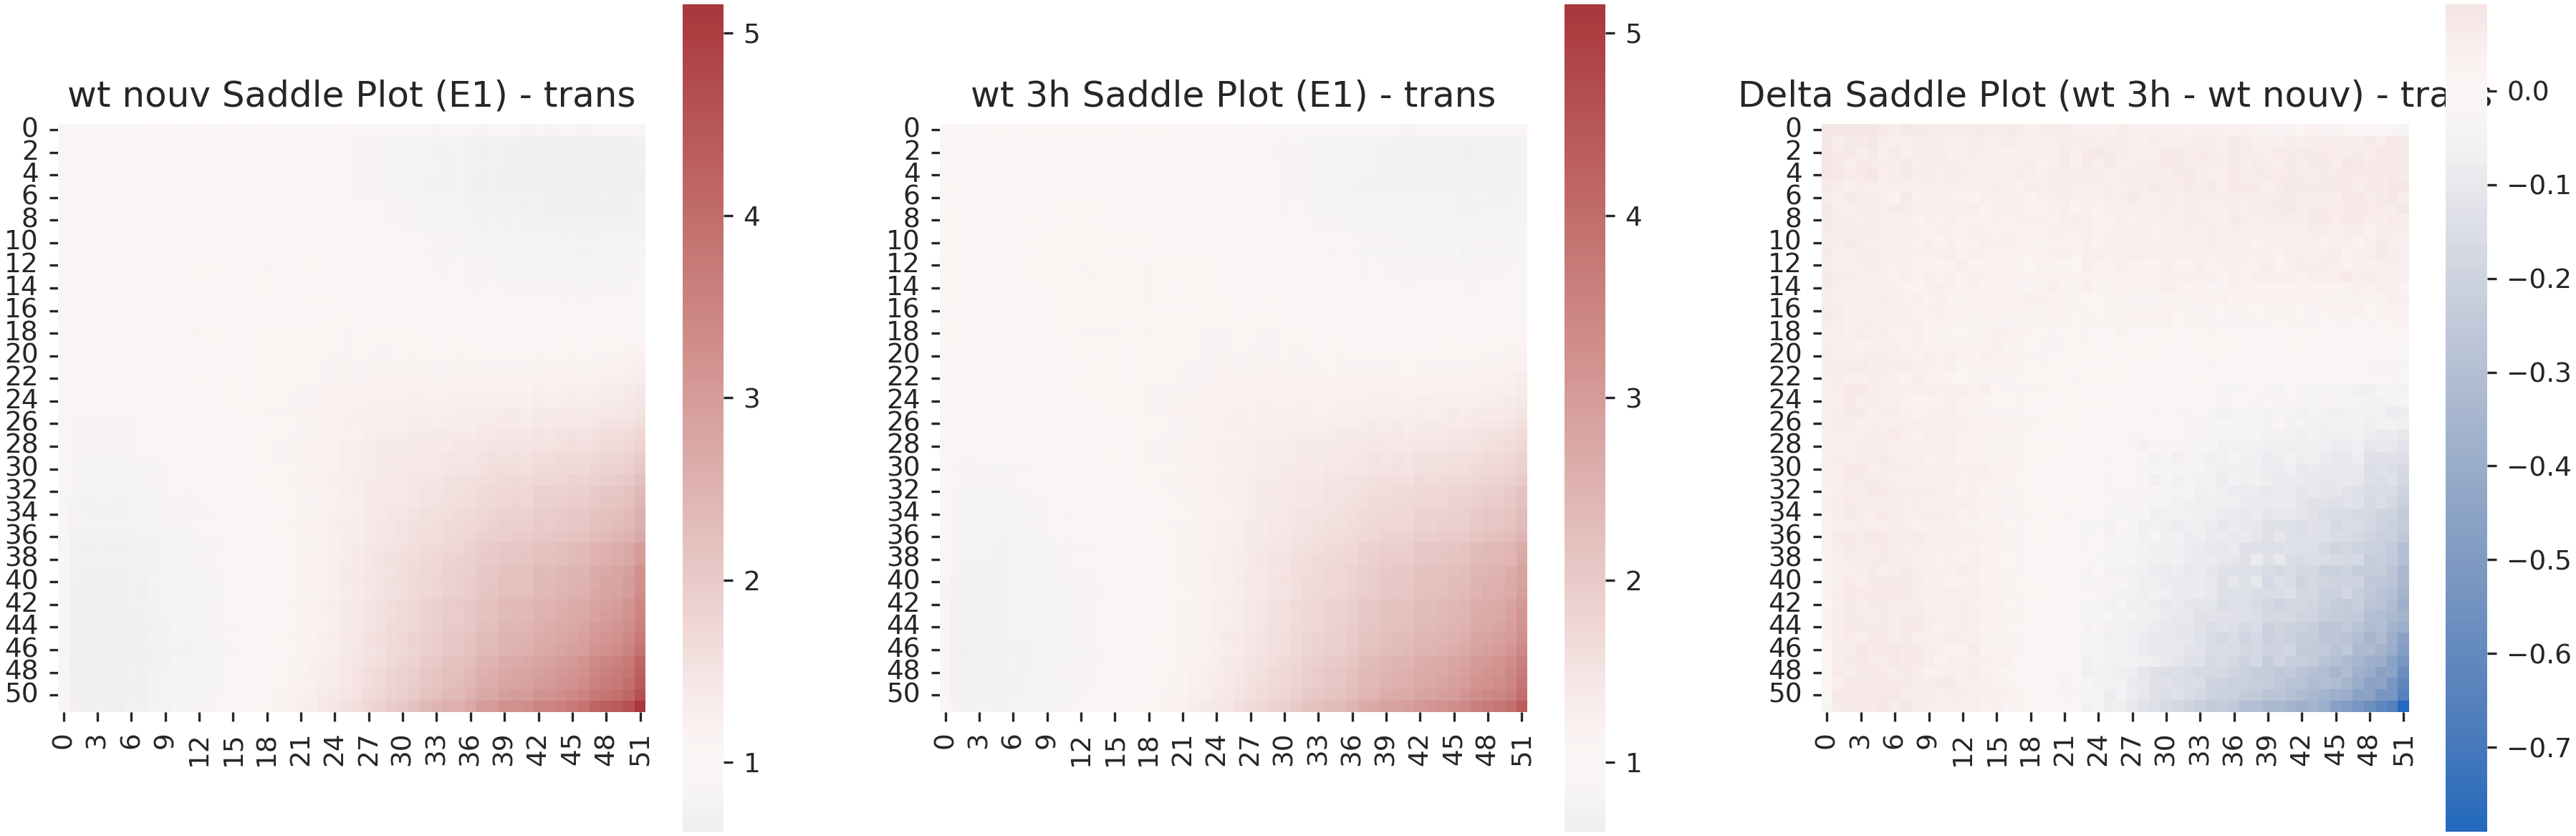

In [32]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

vmin = np.nanmin(interaction_sum_c / interaction_count_c)
vmax = np.nanmax(interaction_sum_c / interaction_count_c)

sns.heatmap(interaction_sum_c / interaction_count_c, cmap='vlag', center=1, ax=axs[0], vmin=vmin, vmax=vmax, square=True)
axs[0].set_title('wt nouv Saddle Plot (E1) - trans')
sns.heatmap(interaction_sum_d / interaction_count_d, cmap='vlag', center=1, ax=axs[1], vmin=vmin, vmax=vmax, square=True)
axs[1].set_title('wt 3h Saddle Plot (E1) - trans')

delta = (interaction_sum_d / interaction_count_d) - (interaction_sum_c / interaction_count_c)
sns.heatmap(delta, cmap='vlag', center=0, ax=axs[2], square=True)
axs[2].set_title('Delta Saddle Plot (wt 3h - wt nouv) - trans')